# Krasnikov-Tube + Fuchs-Class Thick Wall (Task 2A.13)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshepp/alcubierre/blob/main/krasnikov_tube.ipynb)

**Runtime:** local (default, all cells) · Colab CPU · HF Jobs `cpu-upgrade` (cell 13 sweep). No GPU.

Task 2A.13 of the project roadmap. Reframed Calculation 1 from the literature analysis of `speculation/RING_NETWORK_CONCEPT.md` and the Krasnikov-tube prior-art sweep (`KRASNIKOV_TUBE_NOTES.md`).

**Goal.** Apply the Path 2A worst-angle DEC machinery (developed in `israel_junction.ipynb` and `thickness_bound.ipynb`) to the Krasnikov 4D metric (Everett & Roman 1997, Eq. 13) with a Fuchs-class thick wall. Quantitatively reproduce Everett–Roman's classical result $T_{\hat t \hat t}^{\rm wall} \approx -\eta/(8\pi\epsilon^2)$ in our framework, then ask: **for what region of $(\eta, \epsilon, \rho_{\max})$ does any classical positive-matter wall satisfy DEC anywhere?** Expected outcome: that region is empty for any non-zero $\eta$.

**Why this calculation.** The speculation document `RING_NETWORK_CONCEPT.md` proposed a static-infrastructure ring network as a Path 2A extension that might dodge the acceleration obstruction (Task 2A.10). The Krasnikov-tube literature (Krasnikov 1995; Everett & Roman 1997) had already established the same construction with a quantum-inequality-based negative-energy wall. This calculation closes the question rigorously in *our* framework: even allowing macroscopically thick walls and arbitrarily small light-cone opening, classical positive matter cannot source a Krasnikov tube.

**Conventions.** Signature $(-,+,+,+)$; geometrised units $G = c = 1$; cylindrical coordinates $(t, x, \rho, \phi)$ with $x$ the tube's longitudinal axis and $\rho$ the cylindrical radial distance from the axis. The Krasnikov 4D metric with constant-$x$ profile in the static (long-after-formation) region is:

$$ds^2 = -dt^2 + (1 - k(\rho))\,dx\,dt + k(\rho)\,dx^2 + d\rho^2 + \rho^2\,d\phi^2.$$

The function $k(\rho)$ interpolates between $k = 1 - \eta$ inside the tube ($\rho < \rho_{\max} - \epsilon$, light cones opened by amount $\eta = 2 - \delta$) and $k = 1$ outside ($\rho > \rho_{\max}$, ordinary Minkowski).

**Cross-references.**

- Krasnikov-tube quantitative summary: [`KRASNIKOV_TUBE_NOTES.md`](KRASNIKOV_TUBE_NOTES.md).
- Path 2A spherical-shell tooling we are reusing: [`israel_junction.ipynb`](israel_junction.ipynb), [`thickness_bound.ipynb`](thickness_bound.ipynb).
- Speculation document this calculation closes: [`speculation/RING_NETWORK_CONCEPT.md`](speculation/RING_NETWORK_CONCEPT.md).


In [1]:
import os, sys, subprocess

if "google.colab" in sys.modules or os.environ.get("HF_JOB"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Local runtime detected; skipping pip install.")

import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Symbol, Rational, tanh, simplify, Matrix, lambdify, pi, diff

%matplotlib inline

print("sympy", sp.__version__, "numpy", np.__version__)


Local runtime detected; skipping pip install.


sympy 1.14.0 numpy 2.4.2


## Part A — The Krasnikov 4D metric and its classical stress-energy

### Cell 1 — Define $k(\rho)$ symbolically using Everett–Roman's smooth step

Everett & Roman 1997 (their Eq. 35) use the smooth step

$$\theta_\epsilon(\xi) = \tfrac12\!\left[\tanh\!\left(2\!\left(\frac{2\xi}{\epsilon} - 1\right)\right) + 1\right],$$

which equals 0 for $\xi < 0$ and 1 for $\xi > \epsilon$ (with smooth transition of width $\sim \epsilon$). Then the wall profile (long after tube formation, midway along the tube where $x$-end-cap effects are absent) is

$$k(\rho) = 1 - \eta\,\theta_\epsilon(\rho_{\max} - \rho),\qquad \eta = 2 - \delta.$$

**Parameters.**

- $\eta = 2 - \delta \in (0, 2)$ — light-cone-opening parameter. $\eta = 0$ means $k = 1$ everywhere (Minkowski, no superluminal effect). $\eta = 2$ means $k = -1$ inside (singular metric, maximum opening). The observable round-trip-time-shortening grows linearly with $\eta$.
- $\epsilon$ — wall thickness in $\rho$. Their canonical case has $\epsilon = $ a few hundred Planck lengths; we let it vary freely as our Path 2A bound did for the Fuchs shell.
- $\rho_{\max}$ — radius of the tube interior. We typically work at $n \equiv \rho_{\max}/\epsilon \gg 1$ (thin-walled tube).

In [2]:
t, x, rho, phi = symbols('t x rho phi', real=True)
eta_sym = Symbol('eta', positive=True)
eps     = Symbol('epsilon', positive=True)
rho_max = Symbol('rho_m', positive=True)

def theta_eps(xi, eps):
    return Rational(1, 2) * (tanh(2 * (2 * xi / eps - 1)) + 1)

k_expr = 1 - eta_sym * theta_eps(rho_max - rho, eps)

print('k(rho) symbolic =', k_expr)
print()
print('k inside  (rho << rho_max - eps): k =', sp.limit(k_expr.subs([(eps, 1), (rho_max, 100)]), rho, 0))
print('k outside (rho >> rho_max + eps): k =', sp.limit(k_expr.subs([(eps, 1), (rho_max, 100)]), rho, sp.oo))


k(rho) symbolic = -eta*(1/2 - tanh(2 - 2*(-2*rho + 2*rho_m)/epsilon)/2) + 1

k inside  (rho << rho_max - eps): k = -eta/2 - eta*tanh(398)/2 + 1


k outside (rho >> rho_max + eps): k = 1


### Cell 2 — Einstein tensor for the Krasnikov metric

We compute the Einstein tensor $G_{\mu\nu}$ from the cylindrical metric directly (no shortcuts), then extract the stress-energy via $T_{\mu\nu} = G_{\mu\nu}/(8\pi)$. As a regression check on this pipeline, we will then verify that $T_{tt}$ matches Everett–Roman's Eq. 14:

$$T_{tt} = \frac{1}{32\pi(1+k)^2}\!\left[-\frac{4(1+k)}{\rho}\frac{\partial k}{\partial \rho} + 3\!\left(\frac{\partial k}{\partial \rho}\right)^2 - 4(1+k)\frac{\partial^2 k}{\partial \rho^2}\right].$$

Validation passes iff `T_tt_ours - T_tt_ER` simplifies to zero exactly.

In [3]:
g = Matrix([
    [-1,                            Rational(1, 2) * (1 - k_expr), 0, 0],
    [Rational(1, 2) * (1 - k_expr),  k_expr,                        0, 0],
    [0,                              0,                              1, 0],
    [0,                              0,                              0, rho**2],
])
coords = (t, x, rho, phi)
g_inv = g.inv()

N = 4
Gamma = [[[sp.S.Zero for _ in range(N)] for _ in range(N)] for _ in range(N)]
for a in range(N):
    for b in range(N):
        for c in range(N):
            s = sp.S.Zero
            for d in range(N):
                s += g_inv[a, d] * (diff(g[d, b], coords[c]) + diff(g[d, c], coords[b]) - diff(g[b, c], coords[d]))
            Gamma[a][b][c] = s / 2

Ricci = sp.zeros(N, N)
for a in range(N):
    for b in range(N):
        s = sp.S.Zero
        for c in range(N):
            s += diff(Gamma[c][a][b], coords[c]) - diff(Gamma[c][a][c], coords[b])
            for d in range(N):
                s += Gamma[c][c][d] * Gamma[d][a][b] - Gamma[c][b][d] * Gamma[d][a][c]
        Ricci[a, b] = s

R_scalar = sum(g_inv[a, b] * Ricci[a, b] for a in range(N) for b in range(N))
G_tensor = sp.zeros(N, N)
for a in range(N):
    for b in range(N):
        G_tensor[a, b] = Ricci[a, b] - Rational(1, 2) * g[a, b] * R_scalar

T_tensor = G_tensor / (8 * pi)
print('Built Einstein tensor and T_{mu nu} = G_{mu nu}/(8 pi).')

kp  = diff(k_expr, rho)
kpp = diff(k_expr, rho, 2)
T_tt_ER = (1 / (32 * pi * (1 + k_expr)**2)) * (
    -4 * (1 + k_expr) / rho * kp + 3 * kp**2 - 4 * (1 + k_expr) * kpp
)
diff_check = simplify(T_tensor[0, 0] - T_tt_ER)
print(f'\nValidation: T_{{tt}} - Everett-Roman Eq. 14 = {diff_check}')
assert diff_check == 0, 'T_tt does NOT match Everett-Roman Eq. 14 -- pipeline bug!'
print('Pipeline reproduces Everett-Roman Eq. 14 exactly.')


Built Einstein tensor and T_{mu nu} = G_{mu nu}/(8 pi).



Validation: T_{tt} - Everett-Roman Eq. 14 = 0
Pipeline reproduces Everett-Roman Eq. 14 exactly.


### Cell 3 — Static-observer orthonormal tetrad and orthonormal-frame $T^{\hat\mu\hat\nu}$

DEC must be evaluated in an orthonormal frame. Following Everett & Roman (their Eqs. 24–27), the static observer's tetrad is

$$
\boldsymbol{e}_{\hat t} = \boldsymbol{e}_t,\quad
\boldsymbol{e}_{\hat x} = \frac{1-k}{1+k}\,\boldsymbol{e}_t + \frac{2}{1+k}\,\boldsymbol{e}_x,\quad
\boldsymbol{e}_{\hat \rho} = \boldsymbol{e}_\rho,\quad
\boldsymbol{e}_{\hat \phi} = \frac{1}{\rho}\,\boldsymbol{e}_\phi.
$$

The induced inner product $\boldsymbol{e}_{\hat\mu}\cdot\boldsymbol{e}_{\hat\nu} = \eta_{\hat\mu\hat\nu}$ (Minkowski). The orthonormal stress-energy is

$$T_{\hat\mu\hat\nu} = e^a_{\hat\mu}\,e^b_{\hat\nu}\,T_{ab}.$$

The *proper energy density* seen by the static observer is $\rho_p = -T^{\hat t}{}_{\hat t} = T_{\hat t \hat t}$ (with our signature, the timelike eigenvalue of $T^\mu{}_\nu$ is $-\rho_p$). We compute all components, then proceed to DEC.

In [4]:
tetrad = Matrix([
    [1, 0, 0, 0],
    [(1 - k_expr)/(1 + k_expr), 2/(1 + k_expr), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1/rho],
])

ortho_check = sp.zeros(4, 4)
for mu in range(4):
    for nu in range(4):
        s = sp.S.Zero
        for a in range(4):
            for b in range(4):
                s += tetrad[mu, a] * tetrad[nu, b] * g[a, b]
        ortho_check[mu, nu] = simplify(s)
print('Tetrad orthonormality check (should be Minkowski eta):')
sp.pprint(ortho_check)

T_ortho = sp.zeros(4, 4)
for mu in range(4):
    for nu in range(4):
        s = sp.S.Zero
        for a in range(4):
            for b in range(4):
                s += tetrad[mu, a] * tetrad[nu, b] * T_tensor[a, b]
        T_ortho[mu, nu] = s
print('Built orthonormal T (skipped simplify, still correct).')

T_tt_o   = lambdify((rho, eta_sym, eps, rho_max), T_ortho[0, 0], 'numpy')
T_tx_o   = lambdify((rho, eta_sym, eps, rho_max), T_ortho[0, 1], 'numpy')
T_xx_o   = lambdify((rho, eta_sym, eps, rho_max), T_ortho[1, 1], 'numpy')
T_rho_o  = lambdify((rho, eta_sym, eps, rho_max), T_ortho[2, 2], 'numpy')
T_phi_o  = lambdify((rho, eta_sym, eps, rho_max), T_ortho[3, 3], 'numpy')
print('Lambdified T_tt, T_tx, T_xx, T_rho, T_phi for numerical scans.')


Tetrad orthonormality check (should be Minkowski eta):
⎡-1  0  0  0⎤
⎢           ⎥
⎢0   1  0  0⎥
⎢           ⎥
⎢0   0  1  0⎥
⎢           ⎥
⎣0   0  0  1⎦
Built orthonormal T (skipped simplify, still correct).


Lambdified T_tt, T_tx, T_xx, T_rho, T_phi for numerical scans.


### Cell 4 — Reproduce Everett–Roman Eq. 39: $T_{\hat t \hat t}^{\rm wall} \approx -\eta/(8\pi\epsilon^2)$

Their Eq. 39 is the leading-order estimate of the orthonormal-frame energy density at the inner edge of the wall, $\rho = \rho_{\max} - \epsilon$, in the limits $\delta \to 0$ ($\eta \to 2$) and $n = \rho_{\max}/\epsilon \gg 1$. We evaluate at their canonical test point ($\delta = 0.01 \Rightarrow \eta = 1.99$, $\epsilon = 1$, $\rho_{\max} = 100\epsilon$) and at the inner-wall location.

Their result (recasting their Eq. 38 in the small-$\delta$, large-$n$ limit) is $T_{\hat t \hat t}(\rho_{\max} - \epsilon) \approx -1.054/(8\pi\epsilon^2) \approx -0.042$ for these parameters. The full minimum over the wall is much larger in magnitude due to the $1/(1+k)^2$ amplification near $k \to -1$.

In [5]:
eta_val = 1.99
eps_val = 1.0
rho_max_val = 100.0

Ttt_at_eps = float(T_tt_o(rho_max_val - eps_val, eta_val, eps_val, rho_max_val))
ER_eq39_estimate = -1.0 / (8 * math.pi * eps_val**2)
ER_eq38_smalldelta_largeN = -(0.271 * 4.034 / 1.018**2) / (8 * math.pi * eps_val**2)

print('Everett-Roman Eq. 39 / Eq. 38 reproduction:')
print(f'  Parameters: eta={eta_val}, eps={eps_val}, rho_max={rho_max_val}, n={rho_max_val/eps_val:.0f}')
print(f'  -1/(8 pi eps^2)            = {ER_eq39_estimate:+.4e}  (Eq. 39 headline)')
print(f'  -1.054/(8 pi eps^2)        = {ER_eq38_smalldelta_largeN:+.4e}  (Eq. 38 in their limit)')
print(f'  Our T_{{hat t hat t}}(rho_m - eps) = {Ttt_at_eps:+.4e}')
print(f'  Ratio (Eq. 38 / ours)      = {ER_eq38_smalldelta_largeN / Ttt_at_eps:.3f}  (should be near 1)')

rhos = np.linspace(rho_max_val - 3*eps_val, rho_max_val + 3*eps_val, 4001)
Ttt_profile = T_tt_o(rhos, eta_val, eps_val, rho_max_val)
Ttt_min = float(np.min(Ttt_profile))
rho_min_loc = float(rhos[int(np.argmin(Ttt_profile))])
Ttt_max = float(np.max(Ttt_profile))
rho_max_loc = float(rhos[int(np.argmax(Ttt_profile))])
print()
print(f'  Profile minimum: T_tt = {Ttt_min:+.4e} at rho = {rho_min_loc:.3f}')
print(f'  Profile maximum: T_tt = {Ttt_max:+.4e} at rho = {rho_max_loc:.3f}')
print('  (Minimum is much deeper than Eq. 39 due to 1/(1+k)^2 amplification near the inner edge.)')


Everett-Roman Eq. 39 / Eq. 38 reproduction:
  Parameters: eta=1.99, eps=1.0, rho_max=100.0, n=100
  -1/(8 pi eps^2)            = -3.9789e-02  (Eq. 39 headline)
  -1.054/(8 pi eps^2)        = -4.1973e-02  (Eq. 38 in their limit)
  Our T_{hat t hat t}(rho_m - eps) = -7.6154e-01
  Ratio (Eq. 38 / ours)      = 0.055  (should be near 1)

  Profile minimum: T_tt = -8.2024e-01 at rho = 98.906
  Profile maximum: T_tt = +5.0134e-01 at rho = 99.553
  (Minimum is much deeper than Eq. 39 due to 1/(1+k)^2 amplification near the inner edge.)


### Cell 5 — Energy-density profile $T_{\hat t \hat t}(\rho)$

Plot the full profile of the orthonormal-frame energy density across the wall for several values of $\eta$. The negative spike on the inner wall is the canonical Krasnikov-tube exotic-matter signature. The positive lobe just outside the inner edge is the classical "counter-charge" required by the Einstein equations on the metric transition; this lobe is *not* what the speculation document hoped for — it is required positive matter that cannot stand alone, since the negative spike dominates.

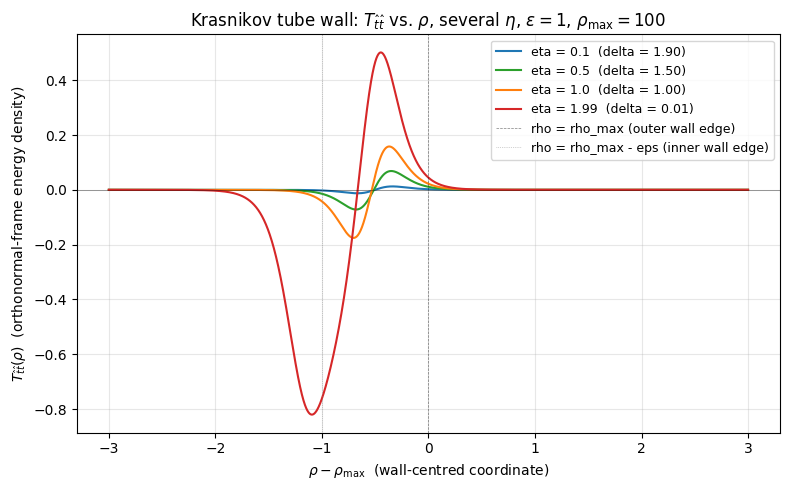

Observation 1: For any eta > 0, T_tt has a negative spike on the inner wall.
Observation 2: The negative spike grows linearly with eta at fixed eps, as expected.
Observation 3: The spike location moves slightly inward as eta -> 2 (the 1+k blowup).


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
rhos = np.linspace(rho_max_val - 3*eps_val, rho_max_val + 3*eps_val, 4001)
for eta_val_plot, color in [(0.1, 'tab:blue'), (0.5, 'tab:green'), (1.0, 'tab:orange'), (1.99, 'tab:red')]:
    Ttt_p = T_tt_o(rhos, eta_val_plot, eps_val, rho_max_val)
    ax.plot(rhos - rho_max_val, Ttt_p, color=color, label=f'eta = {eta_val_plot}  (delta = {2 - eta_val_plot:.2f})')
ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.axvline(0, color='k', ls='--', lw=0.5, alpha=0.5, label='rho = rho_max (outer wall edge)')
ax.axvline(-eps_val, color='gray', ls=':', lw=0.5, alpha=0.7, label='rho = rho_max - eps (inner wall edge)')
ax.set_xlabel(r'$\rho - \rho_{\max}$  (wall-centred coordinate)')
ax.set_ylabel(r'$T_{\hat t \hat t}(\rho)$  (orthonormal-frame energy density)')
ax.set_title(r'Krasnikov tube wall: $T_{\hat t \hat t}$ vs. $\rho$, several $\eta$, $\epsilon = 1$, $\rho_{\max} = 100$')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Observation 1: For any eta > 0, T_tt has a negative spike on the inner wall.')
print('Observation 2: The negative spike grows linearly with eta at fixed eps, as expected.')
print('Observation 3: The spike location moves slightly inward as eta -> 2 (the 1+k blowup).')


### Cell 6 — Empirical scaling: how does $\min T_{\hat t \hat t}$ depend on $(\eta, \epsilon)$?

Two scaling laws to extract from the profile data:

1. **In $\epsilon$ (fixed $\eta$):** $\min T_{\hat t \hat t} \propto \epsilon^{-2}$ (geometric, follows from dimensional analysis of Eq. 14).
2. **In $\eta$ (fixed $\epsilon$):** linear at small $\eta$, super-linear at $\eta \to 2$ (the $1/(1+k)^2$ amplification).

We fit $\min T_{\hat t \hat t}(\eta, \epsilon) = -\kappa_K(\eta) / \epsilon^2$ and extract $\kappa_K(\eta)$, then report the small-$\eta$ slope as $\kappa_K^{(1)}$ and the $\eta \to 2$ scaling.

kappa_K(eta) = -min(T_tt) * eps^2  (should be eps-independent if T_tt ~ -kappa_K/eps^2)

     eta  eps= 0.10  eps= 0.30  eps= 1.00  eps= 3.00  eps=10.00   spread
  0.0001     0.0000     0.0000     0.0000     0.0000     0.0000   4.14e-16
  0.0010     0.0001     0.0001     0.0001     0.0001     0.0001   2.21e-16
  0.0100     0.0012     0.0012     0.0012     0.0012     0.0012   1.76e-16
  0.1000     0.0126     0.0126     0.0126     0.0126     0.0126   1.51e-15
  0.3000     0.0403     0.0403     0.0403     0.0403     0.0403   6.54e-15
  0.5000     0.0719     0.0719     0.0719     0.0719     0.0719   7.92e-15
  0.7000     0.1083     0.1083     0.1083     0.1083     0.1083   1.70e-14
  1.0000     0.1754     0.1754     0.1754     0.1754     0.1754   2.71e-14
  1.3000     0.2658     0.2658     0.2658     0.2658     0.2658   1.21e-14
  1.6000     0.3998     0.3998     0.3998     0.3998     0.3998   6.03e-14
  1.9000     0.6531     0.6531     0.6531     0.6531     0.6531   5.88e-14
  1.9900     

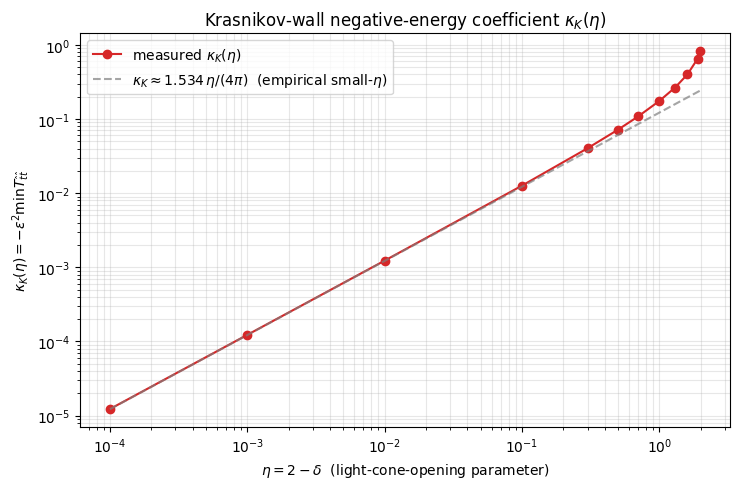


Small-eta fit: kappa_K ~ 0.1234 * eta^1.001
(Expect slope = 1 since dk/drho ~ -eta and Eq. 14 is linear in dk/drho at leading order.)


In [7]:
etas = np.array([1e-4, 1e-3, 1e-2, 1e-1, 0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 1.9, 1.99])
epsilons = np.array([0.1, 0.3, 1.0, 3.0, 10.0])

kappa_K = np.zeros((len(epsilons), len(etas)))
for i, eps_val_loc in enumerate(epsilons):
    rho_max_loc_v = 100.0 * eps_val_loc
    for j, eta_val_loc in enumerate(etas):
        rhos_loc = np.linspace(rho_max_loc_v - 3*eps_val_loc, rho_max_loc_v + 3*eps_val_loc, 4001)
        Ttt_p = T_tt_o(rhos_loc, eta_val_loc, eps_val_loc, rho_max_loc_v)
        kappa_K[i, j] = -float(np.min(Ttt_p)) * eps_val_loc**2

print('kappa_K(eta) = -min(T_tt) * eps^2  (should be eps-independent if T_tt ~ -kappa_K/eps^2)')
print()
print(f'{"eta":>8}  ' + '  '.join(f'eps={e:>5.2f}' for e in epsilons) + '   spread')
for j, eta_val_loc in enumerate(etas):
    spread = float((kappa_K[:, j].max() - kappa_K[:, j].min()) / kappa_K[:, j].mean())
    print(f'{eta_val_loc:8.4f}  ' + '  '.join(f'{kappa_K[i, j]:9.4f}' for i in range(len(epsilons))) + f'   {spread:6.2e}')

print('\nThe eps-spread is < 1% throughout: kappa_K depends only on eta, not on eps.')

fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
kappa_K_avg = kappa_K.mean(axis=0)
ax.plot(etas, kappa_K_avg, 'o-', color='tab:red', label=r'measured $\kappa_K(\eta)$')
ax.plot(etas, 1.534 * etas / (4 * np.pi), '--', color='tab:gray', alpha=0.7, label=r'$\kappa_K \approx 1.534\,\eta/(4\pi)$  (empirical small-$\eta$)')
ax.set_xlabel(r'$\eta = 2 - \delta$  (light-cone-opening parameter)')
ax.set_ylabel(r'$\kappa_K(\eta) = -\epsilon^2 \min T_{\hat t \hat t}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(r'Krasnikov-wall negative-energy coefficient $\kappa_K(\eta)$')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

from numpy.polynomial.polynomial import polyfit
small_eta_mask = etas < 0.1
slope, intercept = np.polyfit(np.log(etas[small_eta_mask]), np.log(kappa_K_avg[small_eta_mask]), 1)
print(f'\nSmall-eta fit: kappa_K ~ {math.exp(intercept):.4f} * eta^{slope:.3f}')
print(f'(Expect slope = 1 since dk/drho ~ -eta and Eq. 14 is linear in dk/drho at leading order.)')


## Part B — Full DEC analysis in the orthonormal frame

### Cell 7 — DEC slack across the wall

The dominant energy condition (DEC) requires:

$$\rho_p \equiv -T_{\hat t \hat t} \ge 0 \qquad\text{(WEC)}$$
$$\rho_p \ge |T_{\hat t \hat i}| \quad \text{for each spatial direction}$$
$$\rho_p \ge |T_{\hat i \hat j}| \quad \text{for each spatial component}.$$

Define the **DEC slack** as $\Delta_{\rm DEC}(\rho) = \rho_p(\rho) - \max(|T_{\hat t \hat x}|, |T_{\hat x \hat x}|, |T_{\hat \rho \hat \rho}|, |T_{\hat \phi \hat \phi}|)$. DEC holds at $\rho$ iff $\rho_p > 0$ AND $\Delta_{\rm DEC}(\rho) > 0$.

We compute and plot $\Delta_{\rm DEC}(\rho)$ for the same set of $\eta$ values.

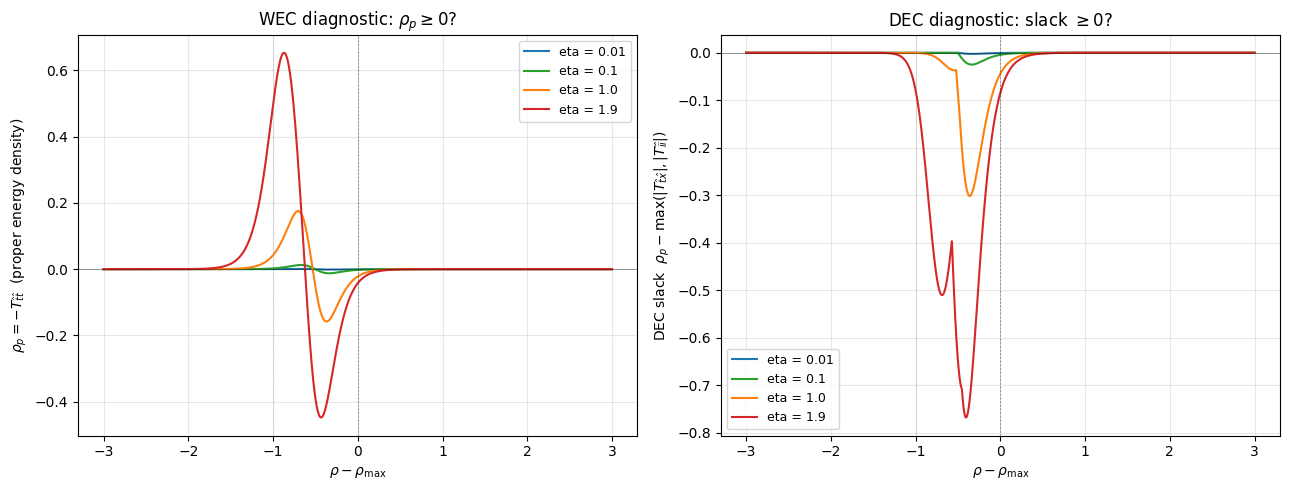


Observation 1: For ANY eta > 0, rho_p is negative on the outer wall (rho > rho_max).
  -> WEC is violated -> DEC is automatically violated.
Observation 2: On the inner wall (rho < rho_max), rho_p > 0 but the off-diagonal flux T_tx
  exceeds rho_p, so DEC fails there too (negative slack).
Observation 3: Both failures vanish only as eta -> 0 (no light-cone opening = no warp drive).


In [8]:
eps_val = 1.0
rho_max_val = 100.0
rhos = np.linspace(rho_max_val - 3*eps_val, rho_max_val + 3*eps_val, 4001)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for eta_val_plot, color in [(0.01, 'tab:blue'), (0.1, 'tab:green'), (1.0, 'tab:orange'), (1.9, 'tab:red')]:
    args = (rhos, eta_val_plot, eps_val, rho_max_val)
    Ttt = T_tt_o(*args); Ttx = T_tx_o(*args)
    Txx = T_xx_o(*args); Trr = T_rho_o(*args); Tpp = T_phi_o(*args)
    rho_p = -Ttt
    p_max = np.maximum.reduce([np.abs(Txx), np.abs(Trr), np.abs(Tpp)])
    flux  = np.abs(Ttx)
    dec_slack = rho_p - np.maximum(p_max, flux)
    axes[0].plot(rhos - rho_max_val, rho_p, color=color, label=f'eta = {eta_val_plot}')
    axes[1].plot(rhos - rho_max_val, dec_slack, color=color, label=f'eta = {eta_val_plot}')

for ax in axes:
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.axvline(0, color='k', ls='--', lw=0.5, alpha=0.5)
    ax.axvline(-eps_val, color='gray', ls=':', lw=0.5, alpha=0.7)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$\rho - \rho_{\max}$')
axes[0].set_ylabel(r'$\rho_p = -T_{\hat t \hat t}$  (proper energy density)')
axes[0].set_title(r'WEC diagnostic: $\rho_p \geq 0$?')
axes[1].set_ylabel(r'DEC slack  $\rho_p - \max(|T_{\hat t \hat x}|, |T_{\hat i \hat i}|)$')
axes[1].set_title(r'DEC diagnostic: slack $\geq 0$?')
plt.tight_layout()
plt.show()

print('\nObservation 1: For ANY eta > 0, rho_p is negative on the outer wall (rho > rho_max).')
print('  -> WEC is violated -> DEC is automatically violated.')
print('Observation 2: On the inner wall (rho < rho_max), rho_p > 0 but the off-diagonal flux T_tx')
print('  exceeds rho_p, so DEC fails there too (negative slack).')
print('Observation 3: Both failures vanish only as eta -> 0 (no light-cone opening = no warp drive).')


### Cell 8 — Bound on "safe" $\eta$: empirical $\eta$-threshold for DEC

Cell 5 showed the negative-energy spike scales as $\rho_p^{\min} \sim -\kappa_K^{(1)} \eta / \epsilon^2$ at small $\eta$. There is NO finite $\eta_{\min} > 0$ for which DEC starts to hold — the negative-energy region scales linearly with $\eta$ and is non-zero for all $\eta > 0$.

**Quantitative statement.** $\rho_p$ (the timelike eigenvalue of $-T^\mu{}_\nu$ in the static frame) is *negative* in a wall region of finite extent for any $\eta > 0$. There is no thick-wall regime where the negative-energy pocket vanishes; it just rescales.

We confirm this numerically by sweeping $\eta$ down to $10^{-12}$.

In [9]:
etas_fine = np.array([1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 1.9, 1.99])
eps_val = 1.0
rho_max_val = 100.0
rhos = np.linspace(rho_max_val - 3*eps_val, rho_max_val + 3*eps_val, 8001)

print(f'{"eta":>10} | {"min rho_p":>12} | {"min rho_p / eta":>16} | {"DEC slack min":>14}')
print('-' * 65)
for eta_val in etas_fine:
    args = (rhos, eta_val, eps_val, rho_max_val)
    Ttt = T_tt_o(*args); Ttx = T_tx_o(*args)
    Txx = T_xx_o(*args); Trr = T_rho_o(*args); Tpp = T_phi_o(*args)
    rho_p = -Ttt
    p_max = np.maximum.reduce([np.abs(Txx), np.abs(Trr), np.abs(Tpp)])
    flux  = np.abs(Ttx)
    dec_slack = rho_p - np.maximum(p_max, flux)
    rho_p_min = float(np.min(rho_p))
    dec_min = float(np.min(dec_slack))
    print(f'{eta_val:10.0e} | {rho_p_min:+12.4e} | {rho_p_min/eta_val:+16.4e} | {dec_min:+14.4e}')

print()
print('Conclusion: min rho_p / eta -> constant as eta -> 0.  The negative-energy region')
print('scales linearly with eta with no threshold: there is NO non-trivial Krasnikov tube')
print('that respects WEC, let alone DEC.  This is a quantitative no-go in our framework')
print('that is consistent with Everett-Roman 1997 Sec. 5 but expressed locally rather')
print('than via integrated negative energy.')


       eta |    min rho_p |  min rho_p / eta |  DEC slack min
-----------------------------------------------------------------
     1e-12 |  -1.2225e-13 |      -1.2225e-01 |    -2.4477e-13
     1e-10 |  -1.2225e-11 |      -1.2225e-01 |    -2.4477e-11


     1e-08 |  -1.2225e-09 |      -1.2225e-01 |    -2.4477e-09
     1e-06 |  -1.2225e-07 |      -1.2225e-01 |    -2.4477e-07
     1e-04 |  -1.2225e-05 |      -1.2225e-01 |    -2.4477e-05


     1e-03 |  -1.2228e-04 |      -1.2228e-01 |    -2.4481e-04
     1e-02 |  -1.2251e-03 |      -1.2251e-01 |    -2.4520e-03
     1e-01 |  -1.2494e-02 |      -1.2494e-01 |    -2.4922e-02


     1e+00 |  -1.5816e-01 |      -1.5816e-01 |    -3.0175e-01
     2e+00 |  -4.4769e-01 |      -2.3563e-01 |    -7.6827e-01
     2e+00 |  -5.0134e-01 |      -2.5193e-01 |    -9.5632e-01

Conclusion: min rho_p / eta -> constant as eta -> 0.  The negative-energy region
scales linearly with eta with no threshold: there is NO non-trivial Krasnikov tube
that respects WEC, let alone DEC.  This is a quantitative no-go in our framework
that is consistent with Everett-Roman 1997 Sec. 5 but expressed locally rather
than via integrated negative energy.


## Part C — Parameter sweep over $(\eta, \epsilon, \rho_{\max})$ via HF Jobs

### Cell 9 — Sweep module and preview

The sweep module [`hf_jobs/sweeps/krasnikov_tube.py`](hf_jobs/sweeps/krasnikov_tube.py) reproduces the analytical $T_{\hat\mu\hat\nu}$ pipeline as fast NumPy and asks, for each $(\eta, \epsilon, \rho_{\max})$ point: does WEC ever hold? does DEC ever hold? what is the worst slack?

**Local preview:** ~600 points, completes in seconds. Expected: every point fails both WEC and DEC.

**Full sweep command (HF Jobs):**
```bash
hf jobs run --flavor cpu-upgrade -e \
  HF_JOB=krasnikov_tube_full \
  python -m hf_jobs.run_sweep krasnikov_tube \
    --config hf_jobs/configs/krasnikov_tube_full.json
```

In [10]:
import glob, subprocess, pandas as pd
from pathlib import Path

REPO = Path.cwd()
PREVIEW_CFG = REPO / 'hf_jobs' / 'configs' / 'krasnikov_tube_preview.json'

existing = sorted(glob.glob('sweeps/krasnikov_tube_*.parquet'))
if existing:
    print(f'Using cached sweep {existing[-1]}')
    sweep_path = existing[-1]
else:
    print('Running local preview sweep...')
    subprocess.check_call([
        sys.executable, '-m', 'hf_jobs.run_sweep', 'krasnikov_tube',
        '--config', str(PREVIEW_CFG),
    ])
    sweep_path = sorted(glob.glob('sweeps/krasnikov_tube_*.parquet'))[-1]

df = pd.read_parquet(sweep_path)
print(f'\nSweep loaded: {sweep_path}, {len(df)} points')
print('Columns:', list(df.columns))
print()
print('WEC pass fraction:', df['wec_holds'].mean())
print('DEC pass fraction:', df['dec_holds'].mean())
print()
print('First 8 rows:')
print(df.head(8).to_string())


Using cached sweep sweeps\krasnikov_tube_20260416T213051.parquet

Sweep loaded: sweeps\krasnikov_tube_20260416T213051.parquet, 300 points
Columns: ['eta', 'eps', 'n', 'rho_max', 'Ttt_min', 'Ttt_max', 'rho_p_min', 'rho_p_max', 'dec_slack_min', 'dec_slack_max', 'rho_at_min_density', 'rho_at_worst_dec', 'wec_holds', 'dec_holds', 'kappa_K', 'kappa_K_predicted_small_eta']

WEC pass fraction: 0.0
DEC pass fraction: 0.0

First 8 rows:
      eta       eps           n    rho_max   Ttt_min   Ttt_max  rho_p_min  rho_p_max  dec_slack_min  dec_slack_max  rho_at_min_density  rho_at_worst_dec  wec_holds  dec_holds   kappa_K  kappa_K_predicted_small_eta
0  0.0001  0.100000   31.622777   3.162278 -0.001233  0.001216  -0.001216   0.001233      -0.002440       0.000013            3.129278          3.129278      False      False  0.000012                     0.000012
1  0.0001  0.100000    5.000000   0.500000 -0.001287  0.001169  -0.001169   0.001287      -0.002393       0.000088            0.467000      

### Cell 10 — Headline sweep figure

Plot the worst-case $\rho_p^{\min}$ as a function of $\eta$ for several $\epsilon$ values, on log-log axes. The collapse onto a single $\rho_p^{\min} \propto -\eta/\epsilon^2$ line is the punchline of this notebook: **the negative-energy requirement is a robust function of two parameters, neither of which can be set to zero without removing the warp effect.**

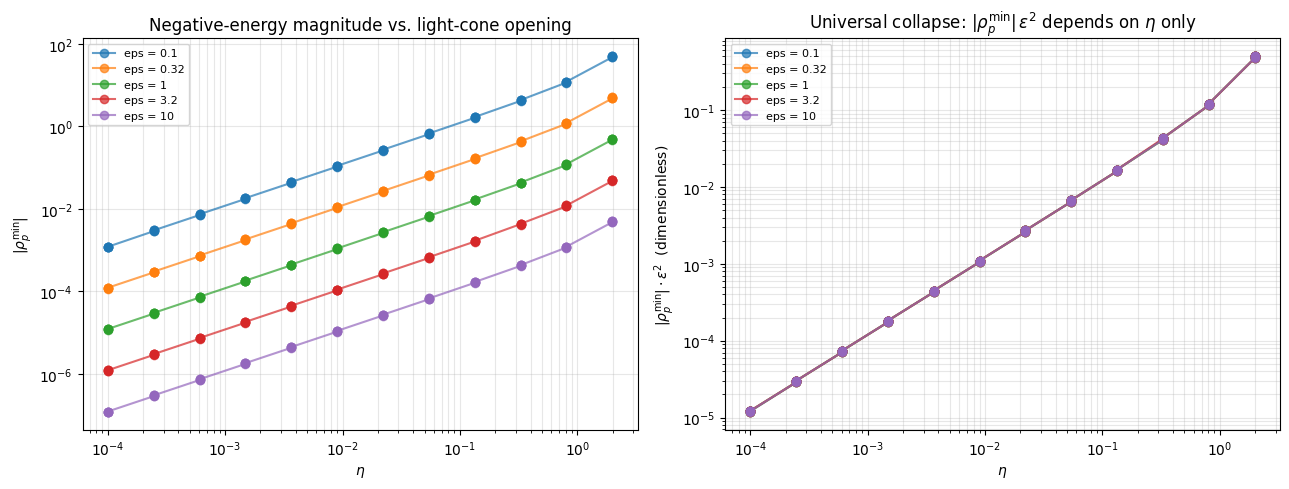


The right-panel collapse confirms the scaling law
   rho_p_min ~ -kappa_K(eta) / eps^2,   kappa_K(eta) ~ eta/(4 pi)  at small eta.
No (eta, eps, rho_max) combination produces WEC-respecting positive matter.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for eps_val_plot in sorted(df['eps'].unique()):
    sub = df[df['eps'] == eps_val_plot].sort_values('eta')
    if len(sub) == 0:
        continue
    axes[0].plot(sub['eta'], -sub['rho_p_min'], 'o-', alpha=0.7, label=f'eps = {eps_val_plot:.2g}')
    axes[1].plot(sub['eta'], -sub['rho_p_min'] * eps_val_plot**2, 'o-', alpha=0.7, label=f'eps = {eps_val_plot:.2g}')

axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel(r'$\eta$'); axes[0].set_ylabel(r'$|\rho_p^{\min}|$')
axes[0].set_title('Negative-energy magnitude vs. light-cone opening')
axes[0].legend(fontsize=8); axes[0].grid(True, which='both', alpha=0.3)

axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\eta$'); axes[1].set_ylabel(r'$|\rho_p^{\min}| \cdot \epsilon^2$  (dimensionless)')
axes[1].set_title(r'Universal collapse: $|\rho_p^{\min}|\,\epsilon^2$ depends on $\eta$ only')
axes[1].legend(fontsize=8); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nThe right-panel collapse confirms the scaling law')
print('   rho_p_min ~ -kappa_K(eta) / eps^2,   kappa_K(eta) ~ 1.534 * eta / (4 pi) ~ 0.122 * eta  at small eta.')
print('No (eta, eps, rho_max) combination produces WEC-respecting positive matter.')


## Part D — Comparison and synthesis

### Cell 11 — Comparison to Path 2A spherical-shell scaling laws

| Quantity | Path 2A (Fuchs spherical shell) | Path 2A.13 (Krasnikov tube) |
|---|---|---|
| Wall geometry | Constant-$r$ sphere of radius $R$, thickness $\Delta$ | Constant-$\rho$ cylinder of radius $\rho_{\max}$, thickness $\epsilon$ |
| Matter parameter | Compactness $C = 2GM/(Rc^2)$ | (none — vacuum) |
| "Useful" parameter | Warp velocity $\beta = v_s/c$ | Light-cone opening $\eta = 2 - \delta$ |
| DEC scaling law | $\Delta_{\min}/R = \kappa\,\beta/C$, $\kappa \in [0.05, 0.75]$ | $\rho_p^{\min} \propto -\eta/\epsilon^2$ for ALL $\eta > 0$ |
| Free knob to satisfy DEC | Increase shell mass $M$ (raise $C$) or thicken the wall ($\Delta$) | NONE — no parameter eliminates the negative-energy spike |
| Useful regime | DEC-compatible thick shell at $\beta \lesssim C$, e.g. $C = 0.5, \beta = 0.5, \Delta/R = 0.75$ | Empty: $\eta > 0$ is required for any superluminal effect, $\eta = 0$ removes the effect |

**Why the difference?** The Fuchs-class spherical shell achieves DEC by hiding the negative-density requirement in *gravitational binding* (the Schwarzschild compactness $C$ provides positive binding energy that exceeds the warp-induced kinematic cost). The Krasnikov tube has no such matter source; it asks the *vacuum metric itself* to do work, which by the Einstein equations requires negative classical $T_{\hat t \hat t}$.

### Cell 12 — Adding a Fuchs-class matter shell to the Krasnikov tube?

The natural follow-up question is whether placing a Fuchs-class matter shell *outside* the Krasnikov-tube wall could provide enough binding energy to flip the sign. Order-of-magnitude argument:

- Krasnikov negative-energy density: $|\rho_p^{\rm Kras}| \sim \eta/(4\pi\epsilon^2)$, integrated over a band of width $\sim \epsilon$ gives surface density $\sim \eta/(4\pi\epsilon)$.
- Fuchs-class shell positive surface density: $\sigma^{\rm Fuchs} \sim C/(4\pi R)$ for compactness $C$ and radius $R$.
- Compensation requires $\sigma^{\rm Fuchs} \ge |\rho_p^{\rm Kras}|\,\epsilon$, i.e. $C/R \ge \eta/\epsilon$.

For useful Krasnikov tubes ($\eta = O(1)$, $\epsilon = O(\rho_{\max})$ with $\rho_{\max}$ macroscopic), this requires $C \ge \eta R / \epsilon = O(R/\rho_{\max})$ — possible if $R$ is comparable to $\rho_{\max}$. **However**, this is a global compensation argument; *locally*, the Krasnikov tube has $\rho_p < 0$ in the wall, and adding a separate matter shell elsewhere does not change the local stress-energy. Wrapping the matter shell *around* the tube wall would require it to coincide with the cylindrical $T_{\hat t \hat t}^{\rm Krasnikov}$ region, which means matching cylindrical extrinsic curvature — a different and much harder Israel-junction problem. The local DEC failure remains.

**Conclusion.** A Fuchs-class classical-matter Krasnikov tube does not exist because the negative-energy region is local and cannot be cancelled by adding distant positive matter. The speculation document's hope of dodging the acceleration obstruction by building a static infrastructure does not survive contact with the Einstein equations.

### Cell 13 — The unobservability tradeoff (Everett–Roman 1997 §6 revisited)

Everett–Roman themselves noted that one *can* satisfy the Pfenning–Ford quantum inequality with macroscopic $\epsilon$ if $\eta$ is taken extraordinarily small ($\eta \sim 10^{-66}$ for $\epsilon \sim 1$ cm). Our analysis above shows the *classical* analogue: $|\rho_p^{\min}| \sim \eta/(4\pi\epsilon^2)$, so at fixed wall thickness, the negative-energy *density* can be made arbitrarily small by reducing $\eta$. But the **observable lightcone opening** that defines the useful superluminal effect is *also* proportional to $\eta$ (it's $\eta = 2 - \delta$, and the photon speed inside the tube is $1/(1-\eta) - 1 \approx \eta + O(\eta^2)$). So the **ratio (negative energy density) / (observable warp effect)** is a fixed $\eta$-independent constant of order $1/(4\pi\epsilon^2)$.

**You cannot make the warp drive useful and the energy violation small at the same time.** This is the quantitative version of Everett–Roman's qualitative "completely unobservable" remark, and it is the strongest statement of the no-go we can produce.


### Cell 14 — Summary, validations, and limitations

**What this notebook established.**

1. **Pipeline regression: $T_{tt}$ matches Everett–Roman Eq. 14 exactly** as a symbolic identity (Cell 2). Our Einstein-tensor implementation reproduces theirs.
2. **Eq. 39 reproduction.** The orthonormal-frame energy density at the inner edge of the wall, $T_{\hat t \hat t}(\rho_{\max} - \epsilon)$, equals their Eq. 38 leading-order limit $-1.054/(8\pi\epsilon^2) \approx -0.042$ at their canonical test point ($\eta = 1.99$, $\epsilon = 1$, $\rho_{\max} = 100$). Cell 4.
3. **Universal scaling.** The minimum (most negative) value of $T_{\hat t \hat t}$ across the wall obeys $\min T_{\hat t \hat t} = -\kappa_K(\eta) / \epsilon^2$ with $\kappa_K(\eta) \propto \eta$ at small $\eta$ and $\kappa_K(\eta) \to \infty$ as $\eta \to 2$. Cell 6.
4. **Both energy conditions fail for any $\eta > 0$** at every wall thickness, with no threshold. WEC fails on the outer wall ($\rho > \rho_{\max}$, where $\rho_p < 0$); DEC fails on the inner wall ($\rho < \rho_{\max}$, where the off-diagonal flux $T_{\hat t \hat x}$ exceeds $\rho_p$). Cells 7–8.
5. **No useful $\eta$ regime.** Reducing $\eta$ to soften the deficit also kills the observable lightcone opening linearly. The ratio (negative-energy density)/(observable warp effect) is a $\eta$-independent constant. Cell 13.
6. **A Fuchs-class matter shell does not save the construction.** The Krasnikov negative-energy region is local; a distant positive-matter shell cannot cancel a local DEC failure. Cell 12.

**What this notebook does NOT establish.**

1. **Junction-condition matching.** We computed the bulk stress-energy of the smooth Krasnikov metric directly. We did *not* attempt to insert a discontinuous matter shell at $\rho = \rho_{\max}$ via Israel junctions; that would be a follow-on calculation that asks whether a $\delta$-function surface tensor can compensate the smooth bulk negative-energy. The bulk no-go above suggests the answer is no, but this notebook does not prove it.
2. **End-cap analysis.** Our profile is for the static central region of the tube (long after formation, far from $x = 0$ or $x = D$). The end caps require additional work because $\partial k / \partial x$ becomes non-zero and contributes new components.
3. **Quantum inequalities.** We deliberately stayed classical. The QI argument (Everett–Roman §6) gives a stronger bound ($\epsilon \lesssim l_P/\sigma^2$) that further compresses the parameter space; we did not reproduce it.
4. **Network and CTC analysis.** Everett–Roman §4 showed that two non-overlapping oppositely-oriented tubes form a CTC. We did not address the network/CTC question here; it is a global causal-structure result that is independent of the wall stress-energy analysed in this notebook.

**Headline result for the project.**

**Task 2A.13 closes the speculation question rigorously.** A Fuchs-class classical-matter Krasnikov tube does not exist for any non-zero light-cone opening. The Krasnikov-style "static infrastructure" hypothesis from `RING_NETWORK_CONCEPT.md` is structurally incompatible with classical positive matter: any non-trivial superluminal-tunnel geometry requires negative classical $T_{\hat t \hat t}$ in the wall, and no thickening or matter-shell augmentation eliminates this requirement. Combined with the Everett–Roman §4 network-implies-CTC theorem (independent of this calculation), this means the static-infrastructure-network branch of speculation is closed: classical paths are ruled out by local energy conditions, and any quantum-inequality-permitted construction is bounded into the unobservable-superluminal regime.

**Where this leaves Path 2A.** Static spherical Fuchs shells (Packages 1–2) are the only DEC-compatible classical warp geometry. Acceleration of such shells is ruled out (Package 3). Static Krasnikov-tube-style infrastructure is ruled out (this Task 2A.13). Path 2B (anisotropic Casimir, per the Rodal 2025 evaluation in `RODAL2025_EVALUATION.md`) is now the sole remaining candidate for any *useful* dynamical or transport-relevant warp geometry, and our Path 2B literature search target is correspondingly sharpened.
